# CS-FEM Demo

This notebook demonstrates how to generate saliency maps using **FEM**, **CS-FEM**, and **Grad-CAM** on a single image with a pretrained ResNet-50.

No dataset download required — we use a sample ImageNet image.

---
**Methods compared:**
- `GradCAM` — gradient-based, class-discriminative
- `FEM` — statistically thresholded, smooth, class-agnostic
- `CSFEM (weights)` — FEM + classifier head weights *(fast, requires a linear classifier head)*
- `CSFEM (gradients)` — FEM + gradient GAP, works on any CNN and matches weights mode for GAP + linear-head architectures.

## 1. Install dependencies

In [ ]:
# Uncomment if running for the first time
# !pip install torch torchvision grad-cam opencv-python matplotlib requests

## 2. Imports

In [1]:
import sys
sys.path.insert(0, '..')   # make csfem/ importable from examples/

import io
import requests
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from pytorch_grad_cam.utils.image import show_cam_on_image

from csfem import FEM, CSFEM, GradCAM

## 3. Load a pretrained ResNet-50

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
model = model.to(device).eval()

# Target layer — last conv block, standard choice for ResNet-50
target_layer = model.layer4[-1]

Using device: cuda


## 4. Load and preprocess an image

We use a publicly available ImageNet sample. You can replace `IMAGE_URL` with any image URL, or load a local file instead.

In [3]:
IMAGE_URL = 'https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg'

# --- Load image ---
response = requests.get(IMAGE_URL, timeout=30)
response.raise_for_status()
pil_image = Image.open(io.BytesIO(response.content)).convert('RGB')

# --- Preprocessing pipeline (standard ImageNet) ---
preprocess = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std= [0.229, 0.224, 0.225]),
])

input_tensor = preprocess(pil_image).unsqueeze(0).to(device)

# --- Visualization background: center-cropped, [0,1] float RGB ---
viz_transform = T.Compose([T.Resize(256), T.CenterCrop(224)])
viz_image = np.array(viz_transform(pil_image)).astype(np.float32) / 255.0

# --- Check predicted class ---
with torch.no_grad():
    logits = model(input_tensor)
predicted_class = logits.argmax(dim=1).item()
print(f'Top predicted ImageNet class index: {predicted_class}')

Top predicted ImageNet class index: 258


## 5. Generate saliency maps

In [4]:
# --- Grad-CAM ---
gradcam = GradCAM(model, target_layer)
saliency_gradcam = gradcam(input_tensor)

# --- FEM (class-agnostic) ---
fem = FEM(model, target_layer)
saliency_fem = fem(input_tensor)
fem.release()

# --- CS-FEM ---
csfem_w = CSFEM(model, target_layer, classifier_layer=model.fc, mode='weights')
saliency_csfem_pos = csfem_w(input_tensor, positive_only=True)
saliency_csfem_comb = csfem_w(input_tensor, positive_only=False)
csfem_w.release()

print('All saliency maps generated.')

All saliency maps generated.


## 6. Visualize

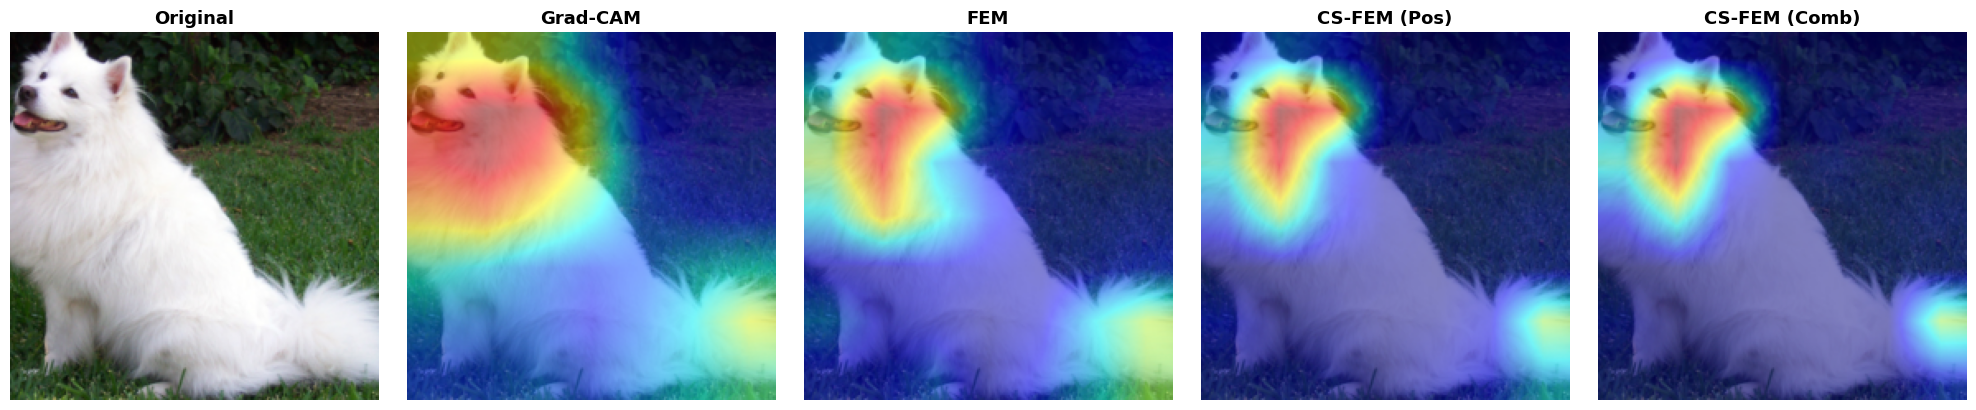

Saved to demo_output_resnet.png


In [5]:
methods = [
    ('Original',              viz_image,                False),
    ('Grad-CAM',              saliency_gradcam,         True),
    ('FEM',                   saliency_fem,             True),
    ('CS-FEM (Pos)',      saliency_csfem_pos,        True),
    ('CS-FEM (Comb)',     saliency_csfem_comb,       True)
]

fig, axes = plt.subplots(1, len(methods), figsize=(20, 4))

for ax, (title, saliency, overlay) in zip(axes, methods):
    if overlay:
        vis = show_cam_on_image(viz_image, saliency, use_rgb=True)
    else:
        vis = (viz_image * 255).astype(np.uint8)
    ax.imshow(vis)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('demo_output_resnet.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to demo_output_resnet.png')

## 7. Other Architectures

For models without a GAP + linear classifier head, use `mode='gradients'`. In this mode, `classifier_layer` is ignored and CS-FEM behaves like a class-specific Grad-CAM-weighted FEM pipeline.

The example below uses VGG16, which has no GAP layer before classification.

In [6]:
vgg_model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg_model = vgg_model.to(device).eval()
vgg_target_layer = vgg_model.features[-1]

In [7]:
# --- Grad-CAM ---
gradcam = GradCAM(vgg_model, vgg_target_layer)
saliency_gradcam = gradcam(input_tensor)

# --- FEM (class-agnostic) ---
fem = FEM(vgg_model, vgg_target_layer)
saliency_fem = fem(input_tensor)
fem.release()

# --- CS-FEM ---
csfem_w = CSFEM(vgg_model, vgg_target_layer, mode='gradients')
saliency_csfem_pos = csfem_w(input_tensor, positive_only=True)
saliency_csfem_comb = csfem_w(input_tensor, positive_only=False)
csfem_w.release()

print('All saliency maps generated.')

All saliency maps generated.


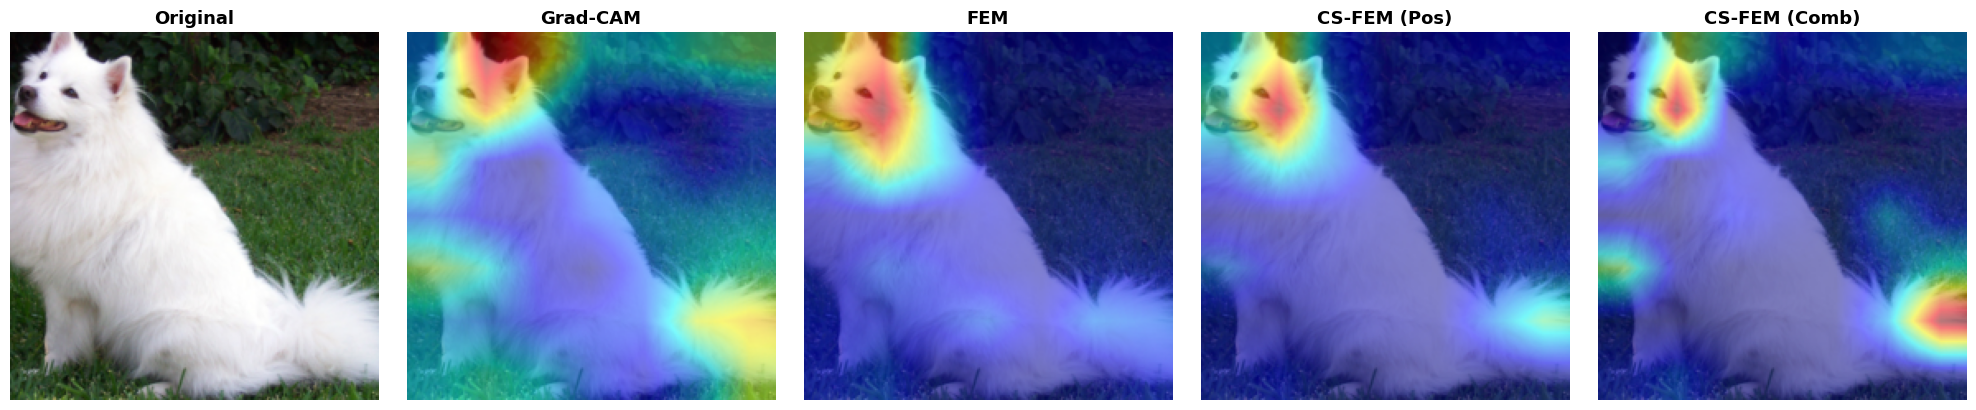

Saved to demo_output_vgg.png


In [8]:
methods = [
    ('Original',              viz_image,                False),
    ('Grad-CAM',              saliency_gradcam,         True),
    ('FEM',                   saliency_fem,             True),
    ('CS-FEM (Pos)',      saliency_csfem_pos,        True),
    ('CS-FEM (Comb)',     saliency_csfem_comb,       True)
]

fig, axes = plt.subplots(1, len(methods), figsize=(20, 4))

for ax, (title, saliency, overlay) in zip(axes, methods):
    if overlay:
        vis = show_cam_on_image(viz_image, saliency, use_rgb=True)
    else:
        vis = (viz_image * 255).astype(np.uint8)
    ax.imshow(vis)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('demo_output_vgg.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to demo_output_vgg.png')

## 8. Using your own image

Replace the loading cell above with the snippet below to use a local file:

```python
pil_image = Image.open('path/to/your/image.jpg').convert('RGB')
```

To explain a specific class rather than the top prediction:

```python
saliency = csfem_w(input_tensor, class_idx=207)  # 207 = golden retriever
```